In [5]:
import pandas as pd

EXCEL_FILE = r"E:\Github\uit_chatbot\system_test\raw_excel\train.xlsx"

# Load Excel
df = pd.read_excel(EXCEL_FILE)

# Randomly select 100 rows
random_df = df.sample(n=300, random_state=42)

# Iterate over rows
for _, row in random_df.iterrows():
    print(row['question'])

CE là mã ký tự đại diện cho Khoa nào?
Chương trình đặc biệt của Trường Đại học Công nghệ Thông tin gồm những chương trình nào?
Ai là người ký quyết định thành lập BĐH?
Mỗi lớp học lý thuyết được cấp 01 website môn học vào thời gian nào?
Có lưu ý gì khi tổ chức các buổi seminar ngoại khóa cho sinh viên?
Khóa luận tốt nghiệp của các sinh viên thuộc chương trình CTTN thì người hướng dẫn phải có trình độ thế nào?
Khi nào thì người có thẩm quyền cấp văn bằng, chứng chỉ bị xử phạt vi phạm hành chính?
Nếu không phải do ĐHQG-HCM in và phát hành chứng chỉ thực hành thì ai sẽ là người nào có thể thay thế trong việc in và phát hành?
Thủ tục cấp lại văn bằng, chứng chỉ ra sao?
Các khóa tuyển sinh trước năm 2022 nếu không tuân theo quy định đào tạo ngoại ngữ đối với hệ đại học chính quy của trường đại học công nghệ thông tin hiện tại thì phải tuân theo quy định nào?
Quy định về thời điểm nộp chứng chỉ để xét miễn tiếng Anh như thế nào?
Sinh viên hệ ĐTTX có được hưởng đặc quyền không?
Lớp học phần s

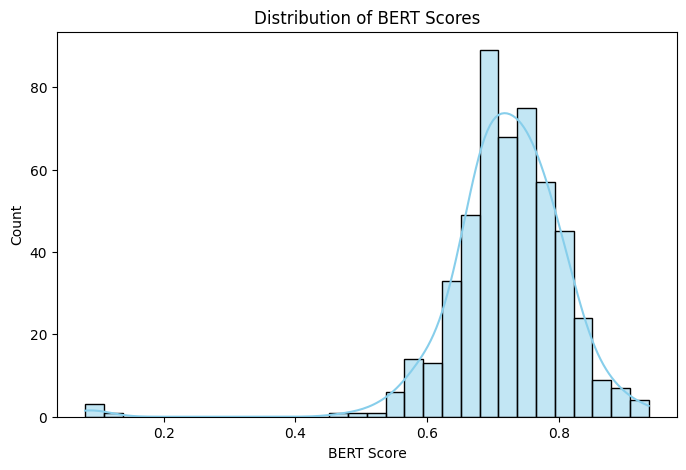

C:\Users\Admin\AppData\Local\Temp\ipykernel_24104\3176807606.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='question_type', y='bert_score', data=df, palette='Set2')


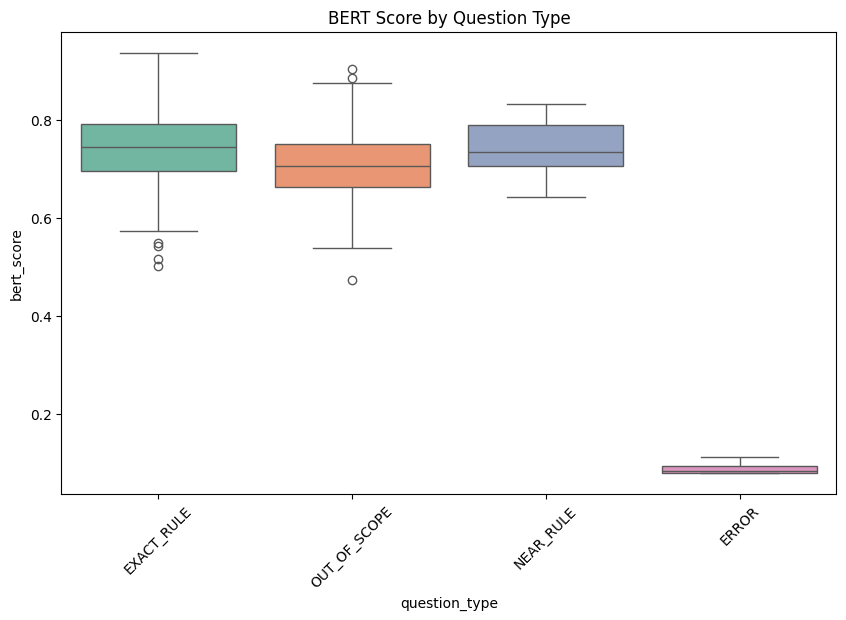

C:\Users\Admin\AppData\Local\Temp\ipykernel_24104\3176807606.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bert_score', y='question', data=worst_bert, palette='Reds_r')


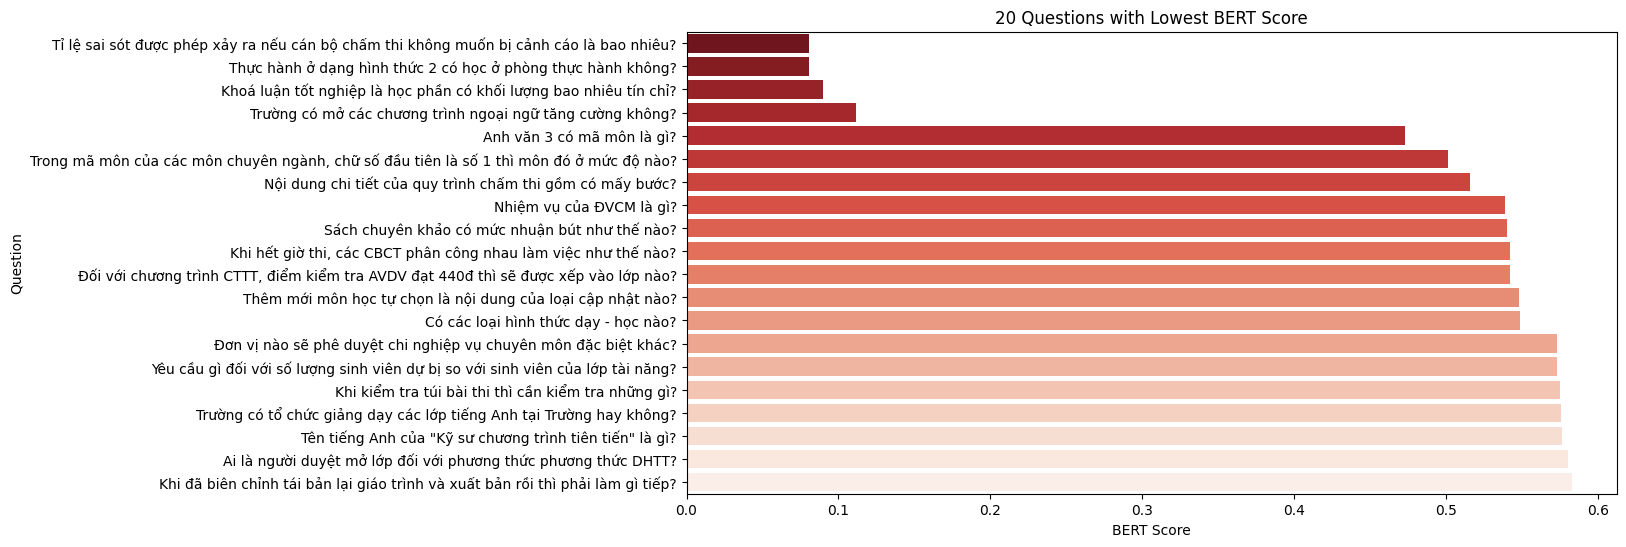

C:\Users\Admin\AppData\Local\Temp\ipykernel_24104\3176807606.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bert_score', y='question', data=best_bert, palette='Greens_r')


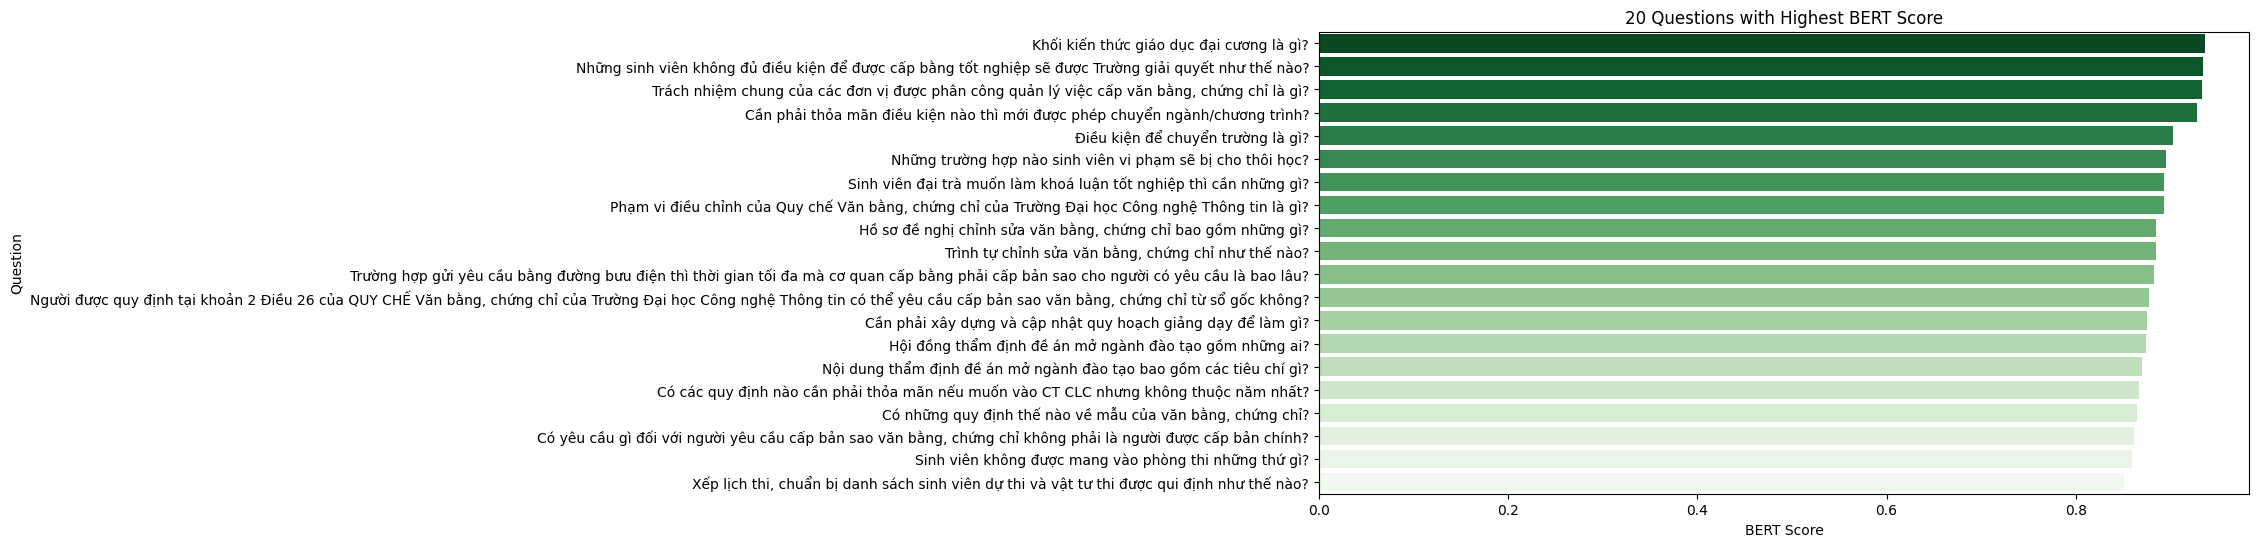

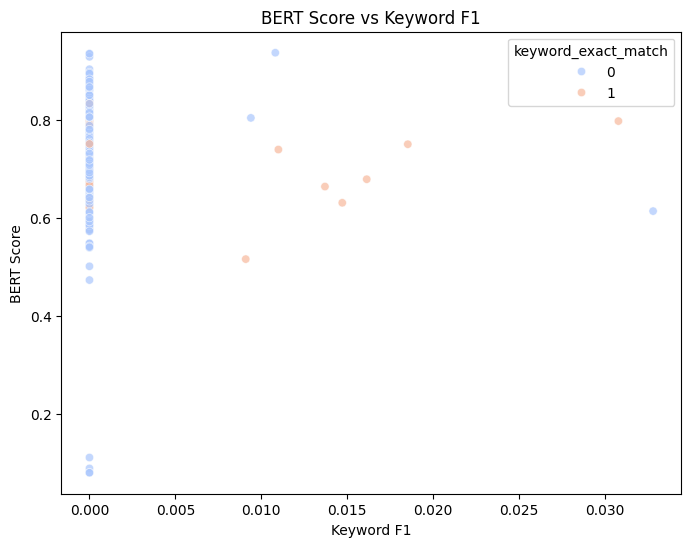

BERT Score Statistics:
count    500.000000
mean       0.720961
std        0.092945
min        0.080709
25%        0.681056
50%        0.726955
75%        0.774305
max        0.936272
Name: bert_score, dtype: float64


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_CSV = r"E:\Github\uit_chatbot\system_test\test_results.csv"

# Load results
df = pd.read_csv(OUTPUT_CSV, encoding='utf-8-sig')

# --- 1. Distribution of BERT scores ---
plt.figure(figsize=(8,5))
sns.histplot(df['bert_score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of BERT Scores')
plt.xlabel('BERT Score')
plt.ylabel('Count')
plt.show()

# --- 2. Boxplot of BERT scores by question type ---
plt.figure(figsize=(10,6))
sns.boxplot(x='question_type', y='bert_score', data=df, palette='Set2')
plt.title('BERT Score by Question Type')
plt.xticks(rotation=45)
plt.show()

# --- 3. Top 20 questions with lowest BERT scores ---
worst_bert = df.nsmallest(20, 'bert_score')
plt.figure(figsize=(12,6))
sns.barplot(x='bert_score', y='question', data=worst_bert, palette='Reds_r')
plt.title('20 Questions with Lowest BERT Score')
plt.xlabel('BERT Score')
plt.ylabel('Question')
plt.show()

# --- 4. Top 20 questions with highest BERT scores ---
best_bert = df.nlargest(20, 'bert_score')
plt.figure(figsize=(12,6))
sns.barplot(x='bert_score', y='question', data=best_bert, palette='Greens_r')
plt.title('20 Questions with Highest BERT Score')
plt.xlabel('BERT Score')
plt.ylabel('Question')
plt.show()

# --- 5. BERT Score vs Exact Match or Keyword F1 ---
plt.figure(figsize=(8,6))
sns.scatterplot(x='keyword_f1', y='bert_score', hue='keyword_exact_match', data=df, palette='coolwarm', alpha=0.7)
plt.title('BERT Score vs Keyword F1')
plt.xlabel('Keyword F1')
plt.ylabel('BERT Score')
plt.show()

# --- 6. Summary statistics of BERT scores ---
print("BERT Score Statistics:")
print(df['bert_score'].describe())

In [29]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util

INPUT_CSV = r"E:\Github\uit_chatbot\system_test\baseline\LLM_only\llm_only_results.csv"
OUTPUT_CSV = r"E:\Github\uit_chatbot\system_test\baseline\LLM_only\recalculate_llm_only_results.csv"

# Load CSV
df = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')

# Load BERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# --- Token-level recall and F1 functions ---
def token_recall_f1(prediction, reference):
    """Token-level recall and F1 between prediction and reference."""
    pred_tokens = set(str(prediction).lower().split())
    ref_tokens = set(str(reference).lower().split())
    common = pred_tokens & ref_tokens
    if not ref_tokens:
        recall = 0.0
    else:
        recall = len(common) / len(ref_tokens)
    if not pred_tokens:
        precision = 0.0
    else:
        precision = len(common) / len(pred_tokens)
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)
    return recall, f1

# --- Recalculate metrics ---
bert_scores = []
recalls = []
f1_scores = []

for idx, row in df.iterrows():
    predicted = str(row['predicted_answer'])
    reference = str(row['abstractive_answer'])

    # BERT similarity
    emb_pred = model.encode([predicted], convert_to_tensor=True)
    emb_ref = model.encode([reference], convert_to_tensor=True)
    bert_sim = util.pytorch_cos_sim(emb_pred, emb_ref).item()

    # Token-level recall and F1
    recall, f1 = token_recall_f1(predicted, reference)

    bert_scores.append(bert_sim)
    recalls.append(recall)
    f1_scores.append(f1)

# --- Update dataframe ---
df['bert_score'] = bert_scores
df['recall'] = recalls
df['f1'] = f1_scores

# Drop old keyword metrics if they exist
if 'keyword_exact_match' in df.columns:
    df.drop(columns=['keyword_exact_match','keyword_f1'], inplace=True)

# Save recalculated CSV
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print(f"Recalculated metrics saved to {OUTPUT_CSV}")

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 39b43f0e-2488-4f6d-b177-62f121c18f9d)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


Recalculated metrics saved to E:\Github\uit_chatbot\system_test\baseline\LLM_only\recalculate_llm_only_results.csv


✓ Successfully loaded 500 rows from Current System
  Filtered out 4 ERROR rows from Current System
✓ Current System: 496 valid rows
✓ Successfully loaded 500 rows from LLM Baseline
  Filtered out 4 ERROR rows from LLM Baseline
✓ LLM Baseline: 496 valid rows

✓ Combined dataset: 992 total rows


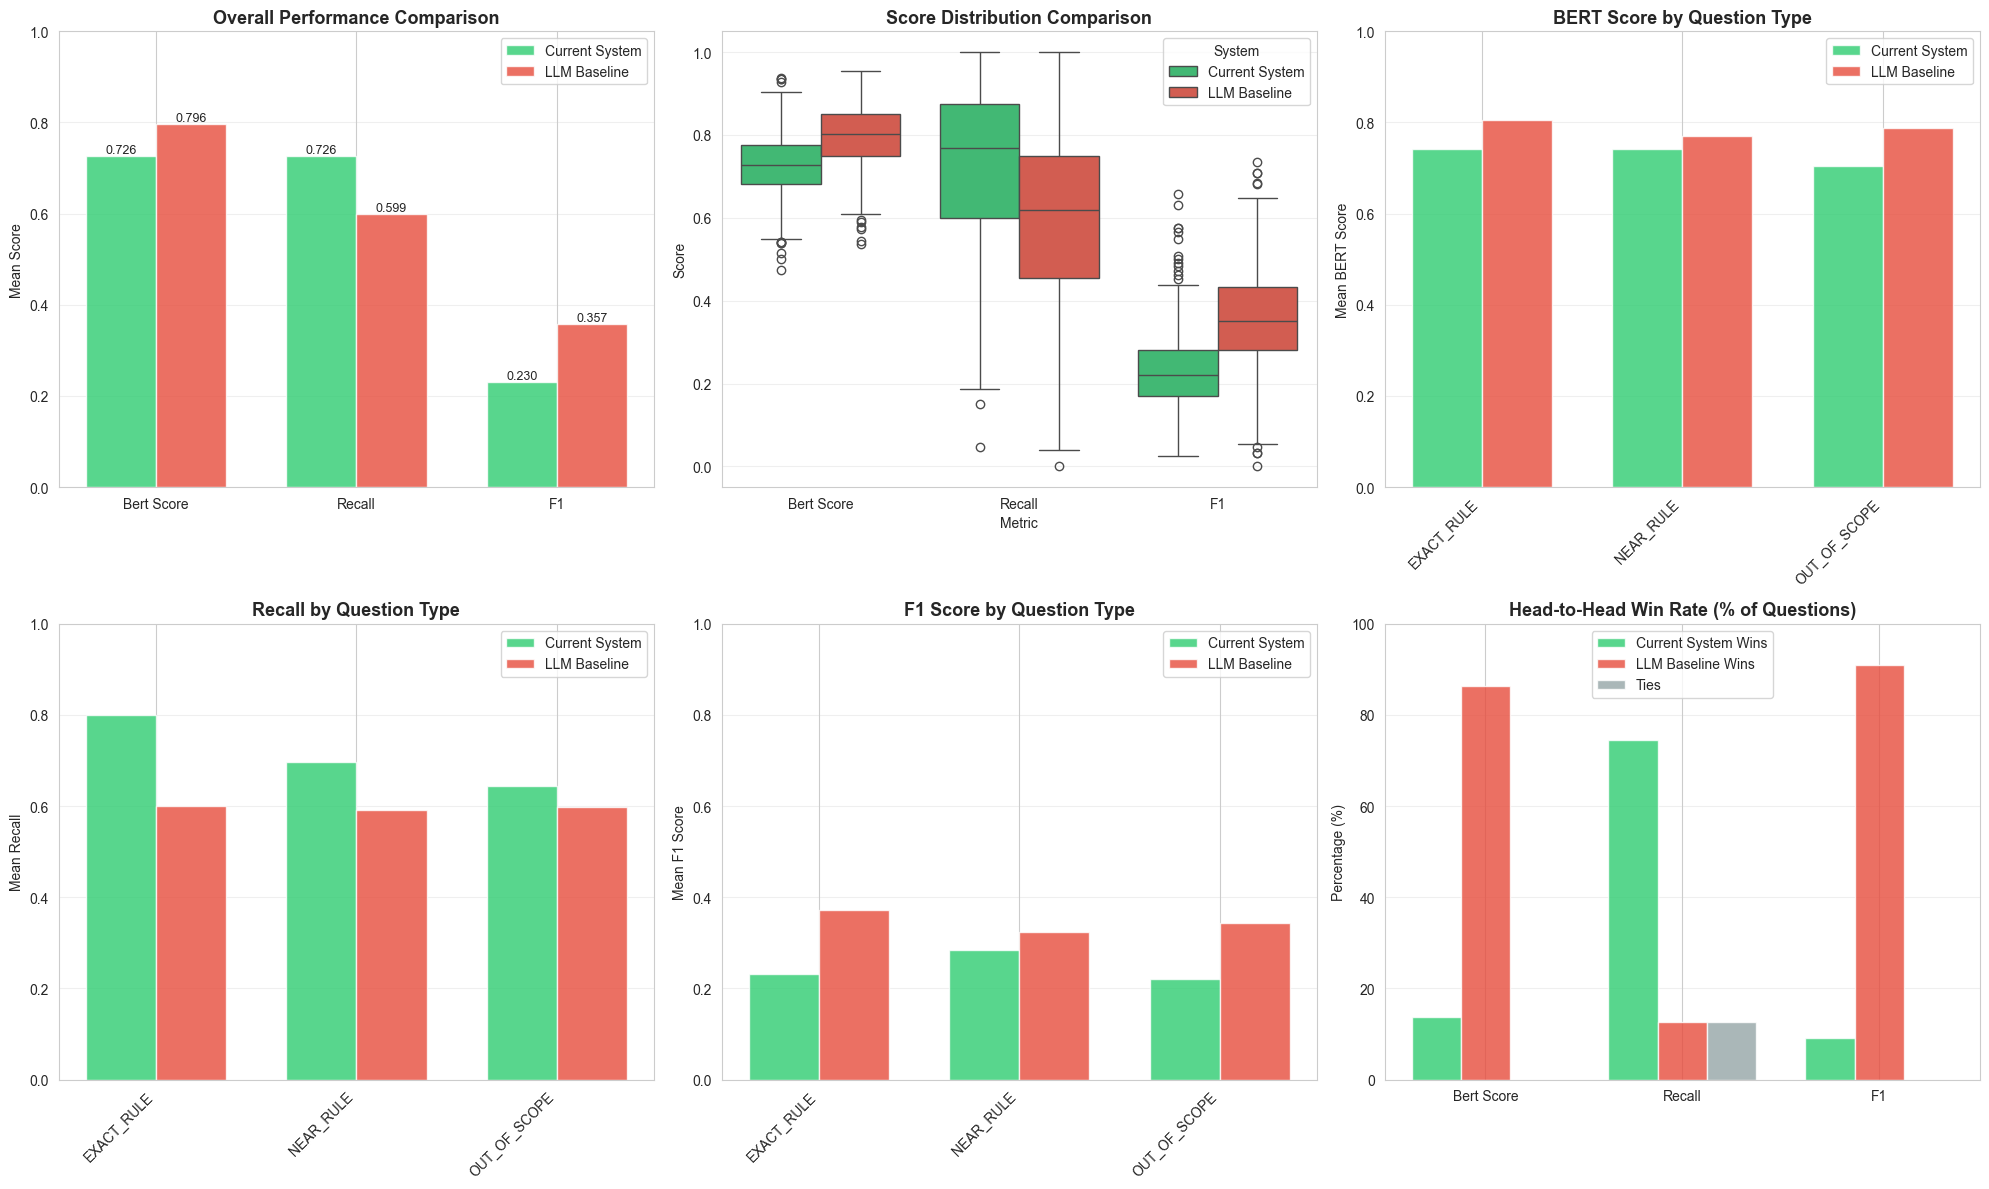

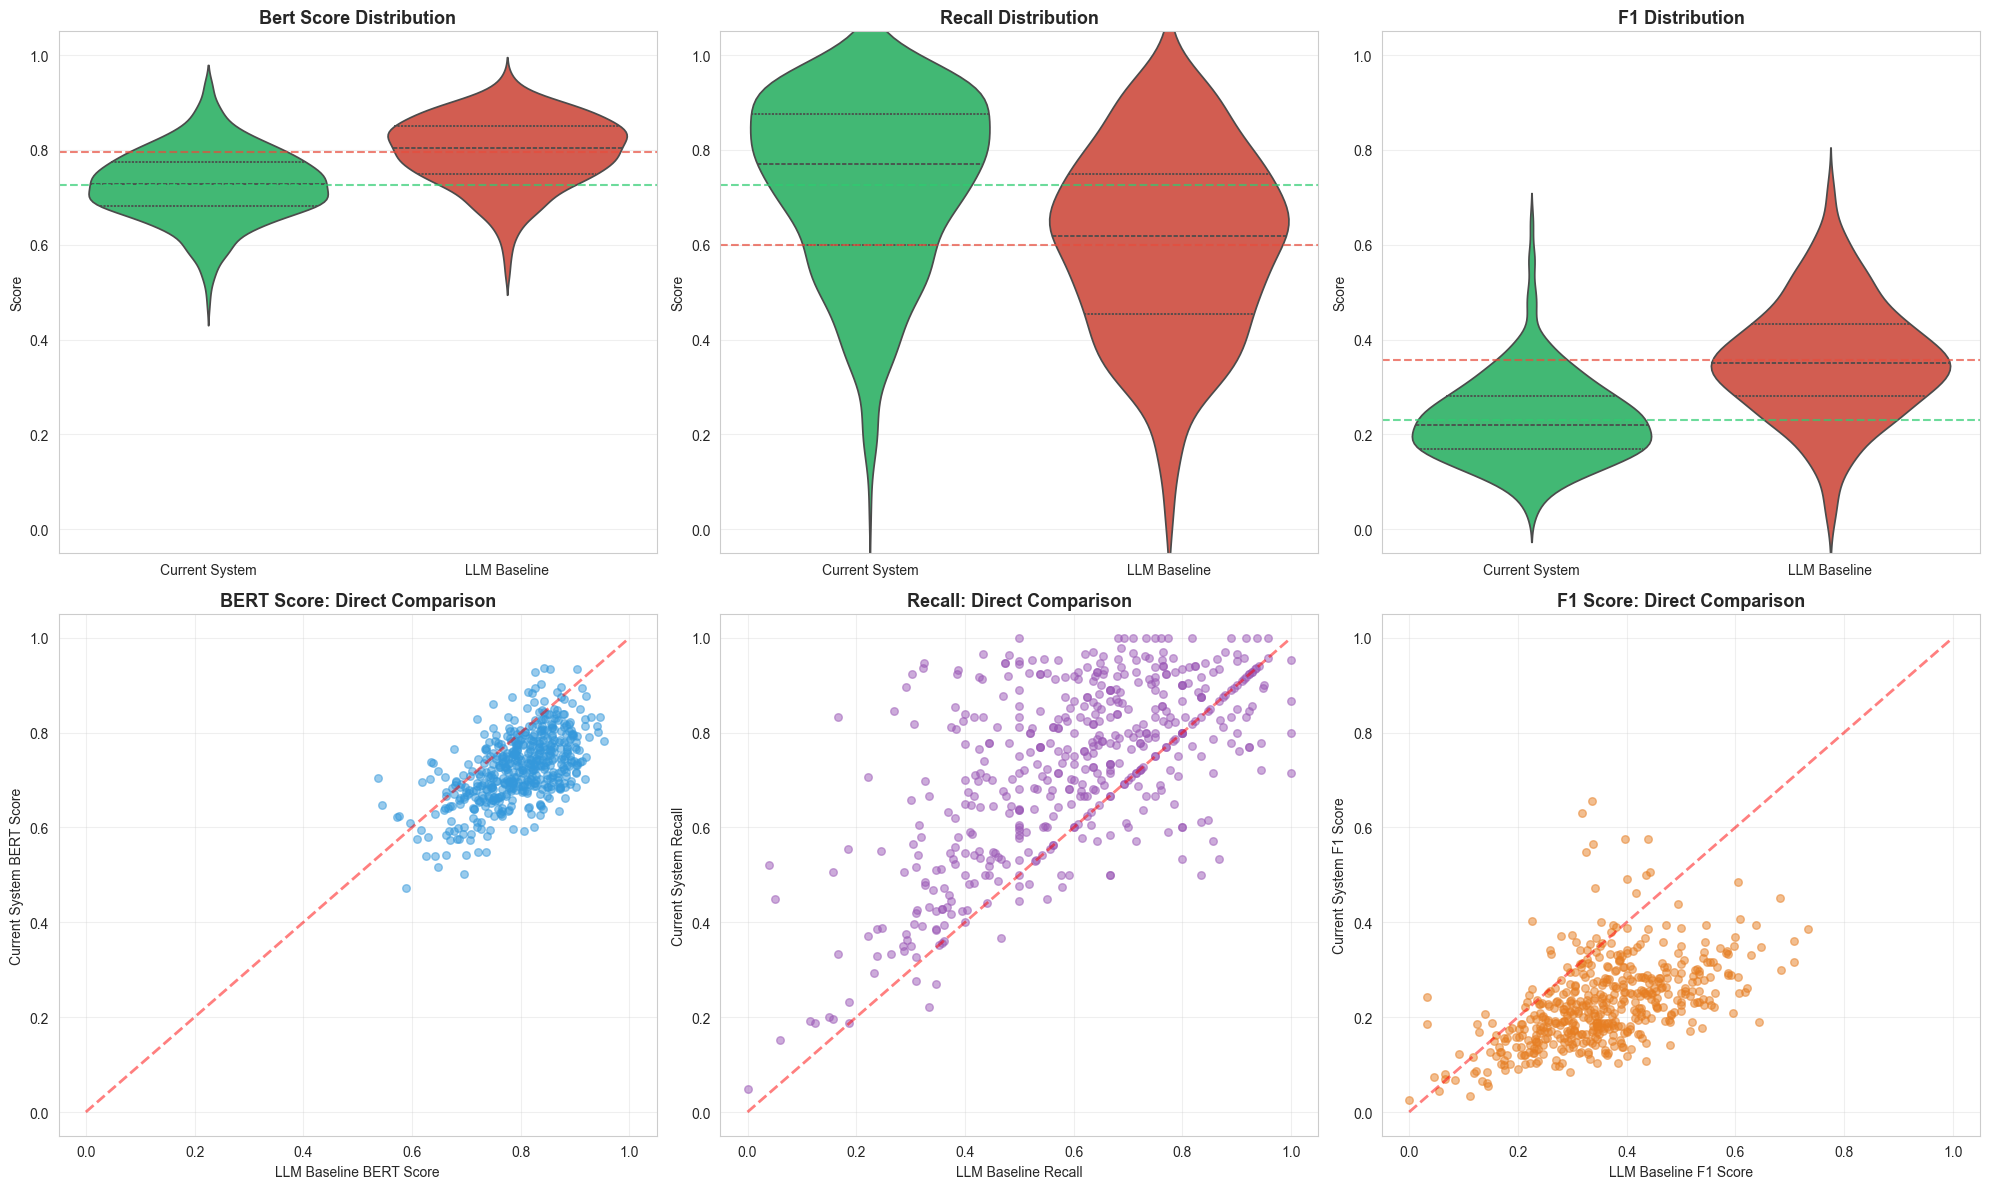


SYSTEM COMPARISON SUMMARY

1. Overall Performance by System:
--------------------------------------------------------------------------------
               bert_score                  recall                      f1  \
                     mean     std  median    mean     std  median    mean   
system                                                                      
Current System     0.7260  0.0740  0.7277  0.7264  0.1873  0.7692  0.2301   
LLM Baseline       0.7959  0.0731  0.8031  0.5994  0.1974  0.6190  0.3572   

                                
                   std  median  
system                          
Current System  0.0912  0.2208  
LLM Baseline    0.1227  0.3505  

2. Performance Improvement (Current System vs LLM Baseline):
--------------------------------------------------------------------------------
Bert Score     : Current=0.7260, Baseline=0.7959, Diff=-0.0699 (-8.78%)
Recall         : Current=0.7264, Baseline=0.5994, Diff=+0.1270 (+21.20%)
F1             : C

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Load data with error handling
SYSTEM1_CSV = r"E:\Github\uit_chatbot\system_test\recalculated_results.csv"
SYSTEM2_CSV = r"E:\Github\uit_chatbot\system_test\baseline\LLM_only\recalculate_llm_only_results.csv"

def load_and_clean_data(filepath, system_name):
    """Load and clean data for a system"""
    try:
        df = pd.read_csv(filepath)
        print(f"✓ Successfully loaded {len(df)} rows from {system_name}")
    except Exception as e:
        print(f"✗ Error loading {system_name}: {e}")
        raise

    # Clean data: convert metrics to numeric
    metrics = ['bert_score', 'recall', 'f1']
    for metric in metrics:
        if metric in df.columns:
            df[metric] = pd.to_numeric(df[metric], errors='coerce')
        else:
            print(f"⚠ Warning: Column '{metric}' not found in {system_name}")
            df[metric] = np.nan

    # Remove rows where ALL metrics are NaN
    df = df.dropna(subset=metrics, how='all')

    # Handle missing question_type and filter out ERROR values
    if 'question_type' not in df.columns:
        df['question_type'] = 'unknown'
    else:
        df['question_type'] = df['question_type'].fillna('unknown')
        original_len = len(df)
        df = df[df['question_type'].str.upper() != 'ERROR']
        removed = original_len - len(df)
        if removed > 0:
            print(f"  Filtered out {removed} ERROR rows from {system_name}")

    df['system'] = system_name
    print(f"✓ {system_name}: {len(df)} valid rows")
    return df

# Load both systems
df_system1 = load_and_clean_data(SYSTEM1_CSV, "Current System")
df_system2 = load_and_clean_data(SYSTEM2_CSV, "LLM Baseline")

# Combine data
df_combined = pd.concat([df_system1, df_system2], ignore_index=True)
metrics = ['bert_score', 'recall', 'f1']

print(f"\n✓ Combined dataset: {len(df_combined)} total rows")

# ============================================================
# FIGURE 1: System Comparison Overview
# ============================================================
fig1 = plt.figure(figsize=(20, 12))

# 1. Overall Mean Scores Comparison (Grouped Bar Chart)
ax1 = plt.subplot(2, 3, 1)
overall_means = df_combined.groupby('system')[metrics].mean()
x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, overall_means.loc['Current System'], width,
                label='Current System', alpha=0.8, color='#2ecc71')
bars2 = ax1.bar(x + width/2, overall_means.loc['LLM Baseline'], width,
                label='LLM Baseline', alpha=0.8, color='#e74c3c')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax1.set_ylabel('Mean Score')
ax1.set_title('Overall Performance Comparison', fontweight='bold', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
ax1.legend()
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', alpha=0.3)

# 2. Side-by-Side Boxplots for All Metrics
ax2 = plt.subplot(2, 3, 2)
metrics_melted = df_combined.melt(id_vars=['system'], value_vars=metrics,
                                   var_name='Metric', value_name='Score')
metrics_melted = metrics_melted.dropna(subset=['Score'])
sns.boxplot(data=metrics_melted, x='Metric', y='Score', hue='system', ax=ax2,
            palette={'Current System': '#2ecc71', 'LLM Baseline': '#e74c3c'})
ax2.set_title('Score Distribution Comparison', fontweight='bold', fontsize=13)
ax2.set_ylabel('Score')
ax2.set_xlabel('Metric')
ax2.set_xticklabels([m.get_text().replace('_', ' ').title() for m in ax2.get_xticklabels()])
ax2.set_ylim(-0.05, 1.05)
ax2.legend(title='System')
ax2.grid(axis='y', alpha=0.3)

# 3. Performance by Question Type - BERT Score
ax3 = plt.subplot(2, 3, 3)
question_types = sorted(df_combined['question_type'].unique())
bert_by_type = df_combined.groupby(['question_type', 'system'])['bert_score'].mean().unstack()
x = np.arange(len(question_types))
width = 0.35
bars1 = ax3.bar(x - width/2, bert_by_type['Current System'], width,
                label='Current System', alpha=0.8, color='#2ecc71')
bars2 = ax3.bar(x + width/2, bert_by_type['LLM Baseline'], width,
                label='LLM Baseline', alpha=0.8, color='#e74c3c')
ax3.set_ylabel('Mean BERT Score')
ax3.set_title('BERT Score by Question Type', fontweight='bold', fontsize=13)
ax3.set_xticks(x)
ax3.set_xticklabels(question_types, rotation=45, ha='right')
ax3.legend()
ax3.set_ylim(0, 1.0)
ax3.grid(axis='y', alpha=0.3)

# 4. Performance by Question Type - Recall
ax4 = plt.subplot(2, 3, 4)
recall_by_type = df_combined.groupby(['question_type', 'system'])['recall'].mean().unstack()
bars1 = ax4.bar(x - width/2, recall_by_type['Current System'], width,
                label='Current System', alpha=0.8, color='#2ecc71')
bars2 = ax4.bar(x + width/2, recall_by_type['LLM Baseline'], width,
                label='LLM Baseline', alpha=0.8, color='#e74c3c')
ax4.set_ylabel('Mean Recall')
ax4.set_title('Recall by Question Type', fontweight='bold', fontsize=13)
ax4.set_xticks(x)
ax4.set_xticklabels(question_types, rotation=45, ha='right')
ax4.legend()
ax4.set_ylim(0, 1.0)
ax4.grid(axis='y', alpha=0.3)

# 5. Performance by Question Type - F1
ax5 = plt.subplot(2, 3, 5)
f1_by_type = df_combined.groupby(['question_type', 'system'])['f1'].mean().unstack()
bars1 = ax5.bar(x - width/2, f1_by_type['Current System'], width,
                label='Current System', alpha=0.8, color='#2ecc71')
bars2 = ax5.bar(x + width/2, f1_by_type['LLM Baseline'], width,
                label='LLM Baseline', alpha=0.8, color='#e74c3c')
ax5.set_ylabel('Mean F1 Score')
ax5.set_title('F1 Score by Question Type', fontweight='bold', fontsize=13)
ax5.set_xticks(x)
ax5.set_xticklabels(question_types, rotation=45, ha='right')
ax5.legend()
ax5.set_ylim(0, 1.0)
ax5.grid(axis='y', alpha=0.3)

# 6. Win Rate Analysis (% questions where each system performs better)
ax6 = plt.subplot(2, 3, 6)
# Merge datasets on question to compare head-to-head
df_s1 = df_system1.set_index('question')[metrics + ['question_type']]
df_s2 = df_system2.set_index('question')[metrics + ['question_type']]
comparison = df_s1.join(df_s2, lsuffix='_s1', rsuffix='_s2', how='inner')

win_rates = []
for metric in metrics:
    s1_wins = (comparison[f'{metric}_s1'] > comparison[f'{metric}_s2']).sum()
    s2_wins = (comparison[f'{metric}_s1'] < comparison[f'{metric}_s2']).sum()
    ties = (comparison[f'{metric}_s1'] == comparison[f'{metric}_s2']).sum()
    total = len(comparison)
    win_rates.append({
        'metric': metric,
        'Current System': s1_wins / total * 100,
        'LLM Baseline': s2_wins / total * 100,
        'Ties': ties / total * 100
    })

win_df = pd.DataFrame(win_rates)
x = np.arange(len(metrics))
width = 0.25
ax6.bar(x - width, win_df['Current System'], width, label='Current System Wins',
        alpha=0.8, color='#2ecc71')
ax6.bar(x, win_df['LLM Baseline'], width, label='LLM Baseline Wins',
        alpha=0.8, color='#e74c3c')
ax6.bar(x + width, win_df['Ties'], width, label='Ties', alpha=0.8, color='#95a5a6')
ax6.set_ylabel('Percentage (%)')
ax6.set_title('Head-to-Head Win Rate (% of Questions)', fontweight='bold', fontsize=13)
ax6.set_xticks(x)
ax6.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
ax6.legend()
ax6.set_ylim(0, 100)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('system_comparison_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: Detailed Metric Analysis
# ============================================================
fig2 = plt.figure(figsize=(20, 12))

# Individual metric violin plots for better distribution view
for idx, metric in enumerate(metrics):
    ax = plt.subplot(2, 3, idx + 1)
    sns.violinplot(data=df_combined, x='system', y=metric, ax=ax,
                   palette={'Current System': '#2ecc71', 'LLM Baseline': '#e74c3c'},
                   inner='quartile')
    ax.set_title(f'{metric.replace("_", " ").title()} Distribution',
                 fontweight='bold', fontsize=13)
    ax.set_ylabel('Score')
    ax.set_xlabel('')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='y', alpha=0.3)

    # Add mean lines
    for system, color in [('Current System', '#2ecc71'), ('LLM Baseline', '#e74c3c')]:
        mean_val = df_combined[df_combined['system'] == system][metric].mean()
        ax.axhline(y=mean_val, color=color, linestyle='--', linewidth=1.5, alpha=0.7)

# Scatter plots comparing systems directly
ax4 = plt.subplot(2, 3, 4)
ax4.scatter(comparison['bert_score_s2'], comparison['bert_score_s1'],
           alpha=0.5, s=30, c='#3498db')
ax4.plot([0, 1], [0, 1], 'r--', alpha=0.5, linewidth=2)
ax4.set_xlabel('LLM Baseline BERT Score')
ax4.set_ylabel('Current System BERT Score')
ax4.set_title('BERT Score: Direct Comparison', fontweight='bold', fontsize=13)
ax4.grid(alpha=0.3)
ax4.set_xlim(-0.05, 1.05)
ax4.set_ylim(-0.05, 1.05)

ax5 = plt.subplot(2, 3, 5)
ax5.scatter(comparison['recall_s2'], comparison['recall_s1'],
           alpha=0.5, s=30, c='#9b59b6')
ax5.plot([0, 1], [0, 1], 'r--', alpha=0.5, linewidth=2)
ax5.set_xlabel('LLM Baseline Recall')
ax5.set_ylabel('Current System Recall')
ax5.set_title('Recall: Direct Comparison', fontweight='bold', fontsize=13)
ax5.grid(alpha=0.3)
ax5.set_xlim(-0.05, 1.05)
ax5.set_ylim(-0.05, 1.05)

ax6 = plt.subplot(2, 3, 6)
ax6.scatter(comparison['f1_s2'], comparison['f1_s1'],
           alpha=0.5, s=30, c='#e67e22')
ax6.plot([0, 1], [0, 1], 'r--', alpha=0.5, linewidth=2)
ax6.set_xlabel('LLM Baseline F1 Score')
ax6.set_ylabel('Current System F1 Score')
ax6.set_title('F1 Score: Direct Comparison', fontweight='bold', fontsize=13)
ax6.grid(alpha=0.3)
ax6.set_xlim(-0.05, 1.05)
ax6.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('system_comparison_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# SUMMARY STATISTICS
# ============================================================
print("\n" + "="*80)
print("SYSTEM COMPARISON SUMMARY")
print("="*80)

print("\n1. Overall Performance by System:")
print("-" * 80)
summary = df_combined.groupby('system')[metrics].agg(['mean', 'std', 'median'])
print(summary.round(4))

print("\n2. Performance Improvement (Current System vs LLM Baseline):")
print("-" * 80)
improvements = {}
for metric in metrics:
    current_mean = df_system1[metric].mean()
    baseline_mean = df_system2[metric].mean()
    diff = current_mean - baseline_mean
    pct_change = (diff / baseline_mean * 100) if baseline_mean != 0 else 0
    improvements[metric] = {
        'Current System': current_mean,
        'LLM Baseline': baseline_mean,
        'Difference': diff,
        'Improvement %': pct_change
    }
    print(f"{metric.replace('_', ' ').title():15s}: "
          f"Current={current_mean:.4f}, Baseline={baseline_mean:.4f}, "
          f"Diff={diff:+.4f} ({pct_change:+.2f}%)")

print("\n3. Performance by Question Type:")
print("-" * 80)
type_comparison = df_combined.groupby(['question_type', 'system'])[metrics].mean()
print(type_comparison.round(4))

print("\n4. Head-to-Head Win/Loss/Tie Analysis:")
print("-" * 80)
print(f"Total questions in common: {len(comparison)}")
for metric in metrics:
    s1_wins = (comparison[f'{metric}_s1'] > comparison[f'{metric}_s2']).sum()
    s2_wins = (comparison[f'{metric}_s1'] < comparison[f'{metric}_s2']).sum()
    ties = (comparison[f'{metric}_s1'] == comparison[f'{metric}_s2']).sum()
    print(f"\n{metric.replace('_', ' ').title()}:")
    print(f"  Current System wins: {s1_wins} ({s1_wins/len(comparison)*100:.1f}%)")
    print(f"  LLM Baseline wins:  {s2_wins} ({s2_wins/len(comparison)*100:.1f}%)")
    print(f"  Ties:                {ties} ({ties/len(comparison)*100:.1f}%)")

print("\n5. Questions Where Current System Significantly Outperforms (diff > 0.2):")
print("-" * 80)
for metric in metrics:
    diff_col = f'{metric}_diff'
    comparison[diff_col] = comparison[f'{metric}_s1'] - comparison[f'{metric}_s2']
    better = comparison[comparison[diff_col] > 0.2].sort_values(diff_col, ascending=False)
    print(f"\n{metric.replace('_', ' ').title()}: {len(better)} questions")
    if len(better) > 0:
        print(better[[f'{metric}_s1', f'{metric}_s2', diff_col]].head(5))

print("\n6. Questions Where LLM Baseline Outperforms (diff < -0.2):")
print("-" * 80)
for metric in metrics:
    diff_col = f'{metric}_diff'
    worse = comparison[comparison[diff_col] < -0.2].sort_values(diff_col)
    print(f"\n{metric.replace('_', ' ').title()}: {len(worse)} questions")
    if len(worse) > 0:
        print(worse[[f'{metric}_s1', f'{metric}_s2', diff_col]].head(5))

print("\n" + "="*80)

In [1]:
import pandas as pd

EXCEL_FILE = r"E:\Github\uit_chatbot\system_test\raw_excel\train.xlsx"
INPUT_CSV = r"E:\Github\uit_chatbot\system_test\test_results.csv"
OUTPUT_CSV = INPUT_CSV

# Load files
df_excel = pd.read_excel(EXCEL_FILE)
df_csv = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

# Keep only needed columns from Excel
df_excel = df_excel[["question", "document"]]

# Merge: add "document" to CSV by matching "question"
df_merged = df_csv.merge(
    df_excel,
    on="question",
    how="left"   # keep all CSV rows
)

# Save back to CSV
df_merged.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print("Added 'document' column to CSV")

Added 'document' column to CSV


In [1]:
import pandas as pd
import sqlite3
from rapidfuzz import process, fuzz
from unidecode import unidecode

DB_PATH = r"E:\Github\uit_chatbot\normailizer\uit_law_points.db"
CSV_PATH = r"E:\Github\uit_chatbot\system_test\test_results.csv"
OUTPUT_CSV = CSV_PATH  # overwrite (or change path)

MATCH_THRESHOLD = 75  # adjust if needed (70–85 typical)

# -------------------------
# Text normalization
# -------------------------
def normalize(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = unidecode(text.lower())
    for ch in [",", ".", "-", "_", "(", ")", "/", "\\"]:
        text = text.replace(ch, " ")
    return " ".join(text.split())


# -------------------------
# Load CSV
# -------------------------
df_csv = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df_csv["document_norm"] = df_csv["document"].apply(normalize)

# -------------------------
# Load DB
# -------------------------
conn = sqlite3.connect(DB_PATH)
df_docs = pd.read_sql(
    "SELECT id, title FROM documents",
    conn
)
conn.close()

df_docs["title_norm"] = df_docs["title"].apply(normalize)

# Prepare matching list
titles = df_docs["title_norm"].tolist()

# -------------------------
# Matching function
# -------------------------
def find_doc_id(doc_norm):
    if not doc_norm:
        return None

    match, score, idx = process.extractOne(
        doc_norm,
        titles,
        scorer=fuzz.token_set_ratio
    )

    if score >= MATCH_THRESHOLD:
        return df_docs.iloc[idx]["id"]
    return None


# -------------------------
# Apply matching
# -------------------------
df_csv["document_id"] = df_csv["document_norm"].apply(find_doc_id)

# Cleanup
df_csv.drop(columns=["document_norm"], inplace=True)

# Save
df_csv.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print("✅ document_id column added")
print("Matched:", df_csv["document_id"].notna().sum())
print("Unmatched:", df_csv["document_id"].isna().sum())

✅ document_id column added
Matched: 381
Unmatched: 124


In [5]:
import pandas as pd
import sqlite3
from rapidfuzz import process, fuzz
from unidecode import unidecode

# ---------------- CONFIG ----------------
TARGET_SIZE = 500

EXCEL_FILE = r"E:\Github\uit_chatbot\system_test\raw_excel\train.xlsx"
OUTPUT_CSV = r"E:\Github\uit_chatbot\system_test\test_question.csv"
DB_PATH = r"E:\Github\uit_chatbot\normailizer\uit_law_points.db"

MATCH_THRESHOLD = 75
# ---------------------------------------


# -------- Text normalization ----------
def normalize(text):
    if not isinstance(text, str):
        return ""
    text = unidecode(text.lower())
    for ch in [",", ".", "-", "_", "(", ")", "/", "\\"]:
        text = text.replace(ch, " ")
    return " ".join(text.split())


# -------- Load DB documents ----------
conn = sqlite3.connect(DB_PATH)
df_docs = pd.read_sql("SELECT id, title FROM documents", conn)
conn.close()

df_docs["title_norm"] = df_docs["title"].apply(normalize)
titles = df_docs["title_norm"].tolist()


def find_doc_id(doc_text):
    doc_norm = normalize(doc_text)
    if not doc_norm:
        return None

    match, score, idx = process.extractOne(
        doc_norm,
        titles,
        scorer=fuzz.token_set_ratio
    )

    if score >= MATCH_THRESHOLD:
        return df_docs.iloc[idx]["id"]
    return None


# -------- Load Excel ----------
df_excel = pd.read_excel(EXCEL_FILE)

REQUIRED_COLS = {
    "question",
    "document",
    "extractive answer",
    "abstractive answer",
}
missing = REQUIRED_COLS - set(df_excel.columns)
if missing:
    raise ValueError(f"Missing columns in Excel: {missing}")

df_excel = df_excel.drop_duplicates(subset="question")


# -------- Build new dataset ----------
rows = []

for _, row in df_excel.iterrows():
    if len(rows) >= TARGET_SIZE:
        break

    doc_id = find_doc_id(row["document"])
    if not doc_id:
        continue

    rows.append({
        "question": row["question"],
        "document": row["document"],
        "document_id": doc_id,
        "abstractive_answer": row["abstractive answer"],
        "extractive_answer": row["extractive answer"],
    })


df_final = pd.DataFrame(rows)

# -------- Save ----------
df_final.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print("✅ New CSV created")
print("Final question count:", len(df_final))

✅ New CSV created
Final question count: 500


In [28]:
import pandas as pd

INPUT_CSV = r"E:\Github\uit_chatbot\system_test\test_results.csv"
df = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')

# Filter OUT_OF_SCOPE questions
out_of_scope_questions = df[df['question_type'] == "OUT_OF_SCOPE"]['question']

# Print each question
for i, q in enumerate(out_of_scope_questions, 1):
    print(f"{i}. {q}")


1. Phương thức dạy học kết hợp là sự kết hợp giữa những hình thức nào?
2. Mức phí mỗi khóa học của CT CLC được công bố khi nào?
3. Nếu như văn bằng, chứng chỉ bị sai thông tin thì sẽ được xử lý thế nào?
4. Địa chỉ trang web của hệ thống UIT-Elearning là gì?
5. Trong trường hợp nào thì Trường sẽ mời giảng viên thỉnh giảng về dạy?
6. Những thành phần nào có khả năng nằm trong học liệu bổ trợ?
7. Tên Tiếng Anh của môn học có bị thay đổi trong cập nhật loại III hay không?
8. CBCT môn thi tại phòng máy có kiểm tra việc kết nối mạng cục bộ của máy tính không?
9. Đơn vị thực hiện công tác xuất lịch thi là ai?
10. Anh văn 3 có mã môn là gì?
11. Dựa vào đâu để nhà trường có thể xếp lớp đầu khóa cho sinh viên?
12. Quy trình gì sau khi thành lập hội đồng thẩm định bản thảo giáo trình?
13. Giảng viên không trực thuộc của Trường là giảng viên gì?
14. Một người có khả năng hoàn thành tốt bổn phận quản lý, cấp phát hoặc sử dụng văn bằng, chứng chỉ không?
15. Giấy tờ xác nhận hợp lệ để Hiệu trưởng xem